# Customer Churn Analysis in E-commerce

## Business Problem
This project aims to identify what drives customer churn in an e-commerce business.

Key questions:
- What percentage of customers churn?
- Are one-time buyers the main source of churn?
- Do review scores, delivery delays, and spending behavior relate to churn?
- What actions can the business take to improve customer retention?

### 1.Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2.load data


In [5]:
df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Documents\cv\project 2 sql + python\customer-churn-analysis-python\olist-ecommerce-dataset\customer_features.csv")
df.head()

,customer_unique_id,first_purchase_date,last_purchase_date,total_orders,total_items,total_spent,avg_order_value,avg_review_score,avg_delivery_days,avg_delivery_delay_days,late_delivery_rate,recency_days,churn_flag,churn_segment
0,eda135af5a64a535f01e6186ecb76da5,2018-03-15 11:02:46.0000000,2018-03-15 11:02:46.0000000,1,1,112.20,112.20,5.0,13.0,-14.0,0.0,167,0,At Risk
1,edacb41488fd3a2f20e311b83848ee79,2018-06-04 12:08:53.0000000,2018-06-04 12:08:53.0000000,1,1,55.64,55.64,2.0,3.0,-21.0,0.0,86,0,Active
2,edb2ea73fbcf58362cc76941af7f3dc7,2017-09-21 15:22:14.0000000,2017-09-21 15:22:14.0000000,1,1,836.16,836.16,1.0,23.0,-4.0,0.0,342,1,Churned
3,edb7c3435d0e6dadfeaf333ba1199f29,2017-06-22 12:55:01.0000000,2017-06-22 12:55:01.0000000,1,1,262.07,262.07,4.0,13.0,-9.0,0.0,433,1,Churned
4,edd286dff982df97e304f16bc5c586b5,2018-08-21 20:10:39.0000000,2018-08-21 20:10:39.0000000,1,1,63.65,63.65,4.0,2.0,-1.0,0.0,8,0,Active


In [6]:
df.shape

(93358, 14)

In [7]:
df.columns

Index(['customer_unique_id', 'first_purchase_date', 'last_purchase_date',
       'total_orders', 'total_items', 'total_spent', 'avg_order_value',
       'avg_review_score', 'avg_delivery_days', 'avg_delivery_delay_days',
       'late_delivery_rate', 'recency_days', 'churn_flag', 'churn_segment'],
      dtype='str')

### 3.Data Overview

1 Xem thông tin dữ liệu

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_unique_id       93358 non-null  str    
 1   first_purchase_date      93358 non-null  str    
 2   last_purchase_date       93358 non-null  str    
 3   total_orders             93358 non-null  int64  
 4   total_items              93358 non-null  int64  
 5   total_spent              93357 non-null  float64
 6   avg_order_value          93357 non-null  float64
 7   avg_review_score         92755 non-null  float64
 8   avg_delivery_days        93350 non-null  float64
 9   avg_delivery_delay_days  93350 non-null  float64
 10  late_delivery_rate       93358 non-null  float64
 11  recency_days             93358 non-null  int64  
 12  churn_flag               93358 non-null  int64  
 13  churn_segment            93358 non-null  str    
dtypes: float64(6), int64(4), str(4)
m

2 Kiểm tra null

In [9]:
df.isnull().sum()

customer_unique_id           0
first_purchase_date          0
last_purchase_date           0
total_orders                 0
total_items                  0
total_spent                  1
avg_order_value              1
avg_review_score           603
avg_delivery_days            8
avg_delivery_delay_days      8
late_delivery_rate           0
recency_days                 0
churn_flag                   0
churn_segment                0
dtype: int64

3 Thống kê mô tả

In [10]:
df.describe()

,total_orders,total_items,total_spent,avg_order_value,avg_review_score,avg_delivery_days,avg_delivery_delay_days,late_delivery_rate,recency_days,churn_flag
count,93358.000000,93358.000000,93357.000000,93357.000000,92755.000000,93350.000000,93350.000000,93358.000000,93358.000000,93358.000000
mean,1.033420,1.180370,165.198772,160.316652,4.153643,12.506644,-11.848272,0.081508,237.478877,0.590544
std,0.209097,0.620857,226.314579,219.572065,1.280158,9.555095,10.138806,0.272118,152.595054,0.491736
min,1.000000,1.000000,9.590000,9.590000,1.000000,0.000000,-147.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,63.060000,62.370000,4.000000,7.000000,-17.000000,0.000000,114.000000,0.000000
50%,1.000000,1.000000,107.780000,105.630000,5.000000,10.000000,-12.000000,0.000000,218.000000,1.000000
75%,1.000000,1.000000,182.560000,176.650000,5.000000,16.000000,-7.000000,0.000000,346.000000,1.000000
max,15.000000,24.000000,13664.080000,13664.080000,5.000000,210.000000,188.000000,1.000000,713.000000,1.000000


4 Xem phân phối churn segment

In [11]:
df["churn_segment"].value_counts()

churn_segment
Churned    55132
At Risk    19706
Active     18520
Name: count, dtype: int64

5 Xem churn rate %

In [12]:
df["churn_segment"].value_counts(normalize=True) * 100

churn_segment
Churned    59.054393
At Risk    21.107993
Active     19.837614
Name: proportion, dtype: float64

In [13]:
df["first_purchase_date"] = pd.to_datetime(df["first_purchase_date"])
df["last_purchase_date"] = pd.to_datetime(df["last_purchase_date"])

In [14]:
df[["first_purchase_date", "last_purchase_date"]].dtypes

first_purchase_date    datetime64[ns]
last_purchase_date     datetime64[ns]
dtype: object

### 4.Churn Analysis

In this section, I analyze customer churn across different customer segments to identify behavioral and operational patterns associated with churn.


4.1 churn rate tổng quan

In [37]:
churn_rate = df["churn_flag"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

df["churn_flag"].value_counts()

Overall churn rate: 59.05%


churn_flag
1    55132
0    38226
Name: count, dtype: int64

4.2customer_type

In [38]:
def classify_customer(order_count):
    if order_count == 1:
        return "One-time buyer"
    else:
        return "Repeat buyer"

df["customer_type"] = df["total_orders"].apply(classify_customer)

df["customer_type"].value_counts()

customer_type
One-time buyer    90557
Repeat buyer       2801
Name: count, dtype: int64

4.3 churn by customer_type

In [39]:
summary_customer_type = df.groupby("customer_type").agg(
    customers=("customer_unique_id", "count"),
    churn_rate=("churn_flag", "mean"),
    avg_orders=("total_orders", "mean"),
    avg_spent=("total_spent", "mean")
).reset_index()

summary_customer_type["churn_rate"] = summary_customer_type["churn_rate"] * 100
summary_customer_type = summary_customer_type.sort_values("churn_rate", ascending=False)

summary_customer_type

,customer_type,customers,churn_rate,avg_orders,avg_spent
0,One-time buyer,90557,59.153903,1.000000,160.763556
1,Repeat buyer,2801,55.837201,2.113888,308.588793


4.4 review_bucket

In [40]:
def review_group(score):
    if score <= 2:
        return "Low (1-2)"
    elif score == 3:
        return "Medium (3)"
    else:
        return "High (4-5)"

df["review_bucket"] = df["avg_review_score"].apply(review_group)

df["review_bucket"].value_counts()

review_bucket
High (4-5)    73905
Low (1-2)     11768
Medium (3)     7685
Name: count, dtype: int64

4.5 churn by review_bucket

In [41]:
summary_review = df.groupby("review_bucket").agg(
    customers=("customer_unique_id", "count"),
    churn_rate=("churn_flag", "mean"),
    avg_delivery_days=("avg_delivery_days", "mean"),
    avg_orders=("total_orders", "mean")
).reset_index()

summary_review["churn_rate"] = summary_review["churn_rate"] * 100
summary_review = summary_review.sort_values("churn_rate", ascending=False)

summary_review

,review_bucket,customers,churn_rate,avg_delivery_days,avg_orders
2,Medium (3),7685,62.355237,14.226677,1.032401
1,Low (1-2),11768,60.978926,20.230122,1.017845
0,High (4-5),73905,58.404709,11.097937,1.036006


4.6 delivery_bucket


In [42]:
def delivery_group(days):
    if days <= 5:
        return "Fast (<=5d)"
    elif days <= 10:
        return "Normal (6-10d)"
    elif days <= 20:
        return "Slow (11-20d)"
    else:
        return "Very Slow (>20d)"

df["delivery_bucket"] = df["avg_delivery_days"].apply(delivery_group)

df["delivery_bucket"].value_counts()

delivery_bucket
Slow (11-20d)       32514
Normal (6-10d)      32121
Fast (<=5d)         15996
Very Slow (>20d)    12727
Name: count, dtype: int64

4.7 churn by delivery_bucket

In [43]:
summary_delivery = df.groupby("delivery_bucket").agg(
    customers=("customer_unique_id", "count"),
    churn_rate=("churn_flag", "mean"),
    avg_review_score=("avg_review_score", "mean"),
    avg_spent=("total_spent", "mean")
).reset_index()

summary_delivery["churn_rate"] = summary_delivery["churn_rate"] * 100

delivery_order = ["Fast (<=5d)", "Normal (6-10d)", "Slow (11-20d)", "Very Slow (>20d)"]
summary_delivery["delivery_bucket"] = pd.Categorical(
    summary_delivery["delivery_bucket"],
    categories=delivery_order,
    ordered=True
)

summary_delivery = summary_delivery.sort_values("delivery_bucket")
summary_delivery

,delivery_bucket,customers,churn_rate,avg_review_score,avg_spent
0,Fast (<=5d),15996,43.323331,4.441986,133.242846
1,Normal (6-10d),32121,54.743003,4.348933,159.363825
2,Slow (11-20d),32514,67.377130,4.205804,176.630430
3,Very Slow (>20d),12727,68.445038,3.155707,190.886529


4.8 spending_segment


In [44]:
q1 = df["total_spent"].quantile(0.25)
q3 = df["total_spent"].quantile(0.75)

def spending_segment(x):
    if x <= q1:
        return "Low spender"
    elif x >= q3:
        return "High spender"
    else:
        return "Mid spender"

df["spending_segment"] = df["total_spent"].apply(spending_segment)

df["spending_segment"].value_counts()

spending_segment
Mid spender     46677
Low spender     23341
High spender    23340
Name: count, dtype: int64

4.9 churn by spending_segment

In [45]:
summary_spending = df.groupby("spending_segment").agg(
    customers=("customer_unique_id", "count"),
    churn_rate=("churn_flag", "mean"),
    avg_orders=("total_orders", "mean"),
    avg_order_value=("avg_order_value", "mean")
).reset_index()

summary_spending["churn_rate"] = summary_spending["churn_rate"] * 100

spending_order = ["Low spender", "Mid spender", "High spender"]
summary_spending["spending_segment"] = pd.Categorical(
    summary_spending["spending_segment"],
    categories=spending_order,
    ordered=True
)

summary_spending = summary_spending.sort_values("spending_segment")
summary_spending

,spending_segment,customers,churn_rate,avg_orders,avg_order_value
1,Low spender,23341,59.851763,1.002142,43.542509
2,Mid spender,46677,59.262592,1.021917,110.893521
0,High spender,23340,57.840617,1.087704,375.933592


### Key Findings from Churn Analysis

- One-time buyers tend to show a higher churn rate than repeat buyers.
- Customers with slower delivery times are more likely to churn.
- Lower review scores are associated with higher churn, although the effect is weaker than delivery performance.
- Spending level provides additional segmentation value, but operational experience appears to be more important than monetary value alone.

## 5. Data Visualization

This section visualizes churn patterns across key customer groups to make the analysis easier to interpret.

1.chart churn by customer type

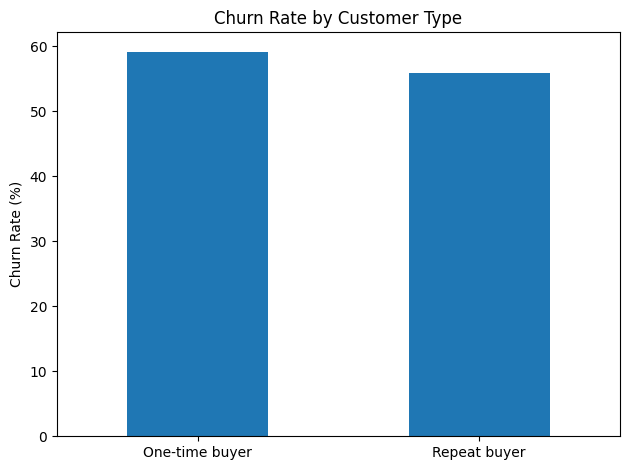

In [46]:
summary_customer_type.plot(
    x="customer_type",
    y="churn_rate",
    kind="bar",
    legend=False,
    title="Churn Rate by Customer Type"
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

2.chart churn by delivery speed

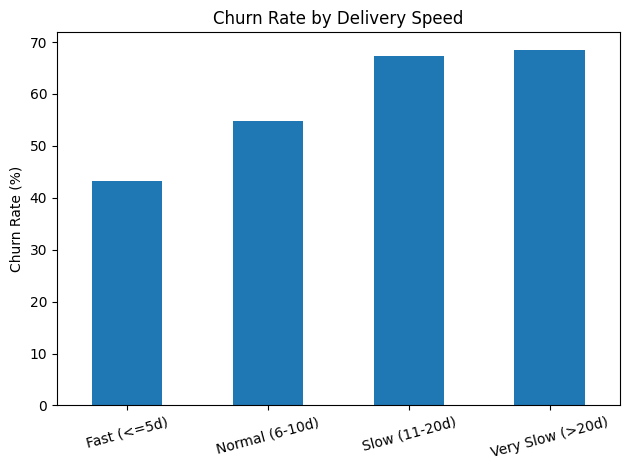

In [47]:
summary_delivery.plot(
    x="delivery_bucket",
    y="churn_rate",
    kind="bar",
    legend=False,
    title="Churn Rate by Delivery Speed"
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

3.chart churn by review bucket

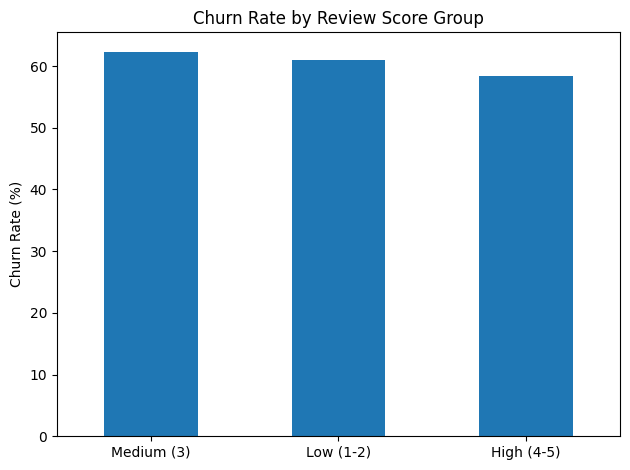

In [48]:
summary_review.plot(
    x="review_bucket",
    y="churn_rate",
    kind="bar",
    legend=False,
    title="Churn Rate by Review Score Group"
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

4.chart churn by spending segment

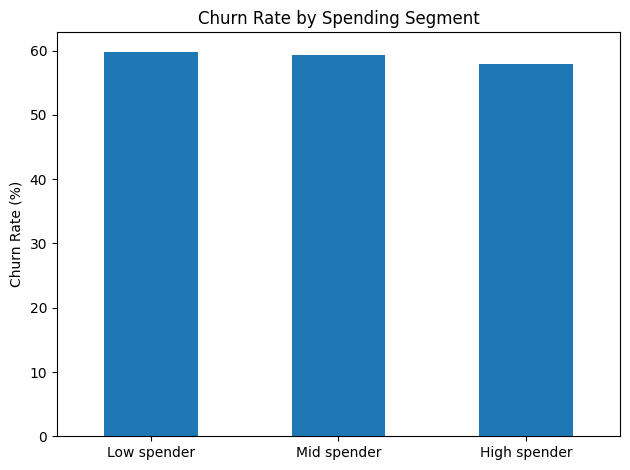

In [49]:
summary_spending.plot(
    x="spending_segment",
    y="churn_rate",
    kind="bar",
    legend=False,
    title="Churn Rate by Spending Segment"
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Baseline Churn Prediction Model

In this section, I build a simple baseline model to predict churn risk using non-leakage features.

## A train/test split

In [57]:
from sklearn.model_selection import train_test_split

features = [
    "total_orders",
    "total_items",
    "total_spent",
    "avg_order_value",
    "avg_review_score",
    "avg_delivery_days",
    "avg_delivery_delay_days",
    "late_delivery_rate"
]

X = df[features]
y = df["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## B Logistic Regression

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, features)
])

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_prob_log = log_model.predict_proba(X_test)[:, 1]
y_pred_log = log_model.predict(X_test)

print("Logistic Regression AUC:", round(roc_auc_score(y_test, y_pred_prob_log), 3))
print(classification_report(y_test, y_pred_log))

Logistic Regression AUC: 0.629
              precision    recall  f1-score   support

           0       0.61      0.29      0.39      7645
           1       0.64      0.87      0.74     11027

    accuracy                           0.63     18672
   macro avg       0.62      0.58      0.56     18672
weighted avg       0.63      0.63      0.60     18672



## C Random forest


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), features)
    ])),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

print("Random Forest AUC:", round(roc_auc_score(y_test, y_pred_prob_rf), 3))
print(classification_report(y_test, y_pred_rf))

Random Forest AUC: 0.673
              precision    recall  f1-score   support

           0       0.57      0.47      0.52      7645
           1       0.67      0.76      0.71     11027

    accuracy                           0.64     18672
   macro avg       0.62      0.62      0.62     18672
weighted avg       0.63      0.64      0.63     18672



## D Feature importance

In [58]:
rf = rf_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
2,total_spent,0.315072
3,avg_order_value,0.314211
6,avg_delivery_delay_days,0.161850
5,avg_delivery_days,0.148881
4,avg_review_score,0.035437
1,total_items,0.018285
7,late_delivery_rate,0.003424
0,total_orders,0.002840


# Insight Model
A leakage-free baseline churn model was developed using customer purchase behavior and service experience features. Random Forest outperformed Logistic Regression with an AUC of 0.673, suggesting moderate predictive power. The most influential factors were spending level, order value, and delivery performance, indicating that both customer value and operational experience are closely associated with churn risk.

# 7 feature importance chart

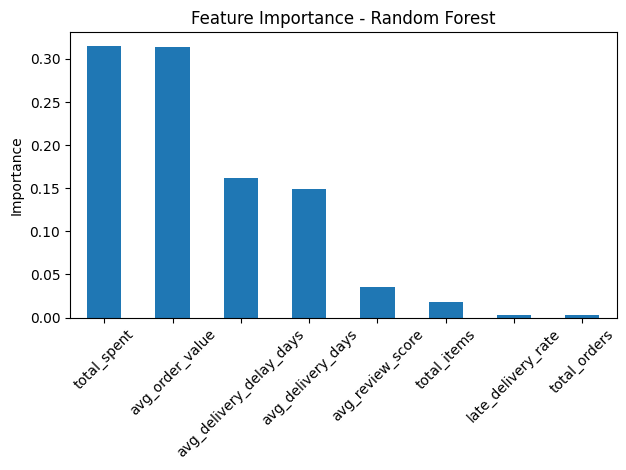

In [59]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False,
    title="Feature Importance - Random Forest"
)

plt.ylabel("Importance")
plt.xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
summary_customer_type.to_csv("summary_customer_type.csv", index=False)
summary_review.to_csv("summary_review.csv", index=False)
summary_delivery.to_csv("summary_delivery.csv", index=False)
summary_spending.to_csv("summary_spending.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)

## Conclusion

This analysis explored customer churn behavior in an e-commerce dataset using customer-level features engineered in SQL and analyzed in Python.

Key findings:
- One-time buyers show a higher churn tendency than repeat buyers.
- Delivery performance is one of the strongest operational signals associated with churn.
- Spending-related features such as total spending and average order value are important predictors of churn.
- Among the tested models, Random Forest performed better than Logistic Regression, achieving an AUC of 0.673.

Overall, the results suggest that both customer purchase behavior and post-purchase experience are important for churn reduction strategies.